<a href="https://colab.research.google.com/github/muhammad-faizan087/Machine-Learning-Projects/blob/main/Linear%20Regression/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(r'/content/drive/MyDrive/ford.csv')

In [ ]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [ ]:
df.shape

(17966, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [ ]:
df.duplicated().sum()

np.int64(154)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(17812, 9)

<Axes: xlabel='price', ylabel='Count'>

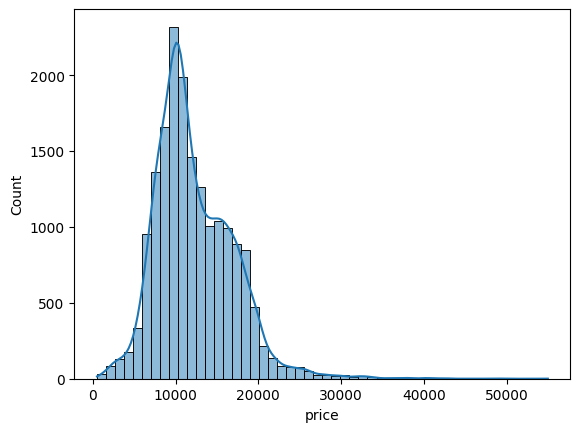

In [ ]:
sns.histplot(df['price'], bins=50, kde=True)


<Axes: >

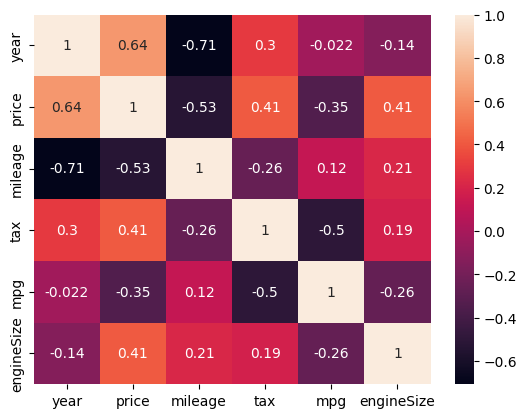

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
categorical_cols = ['model', 'transmission', 'fuelType']

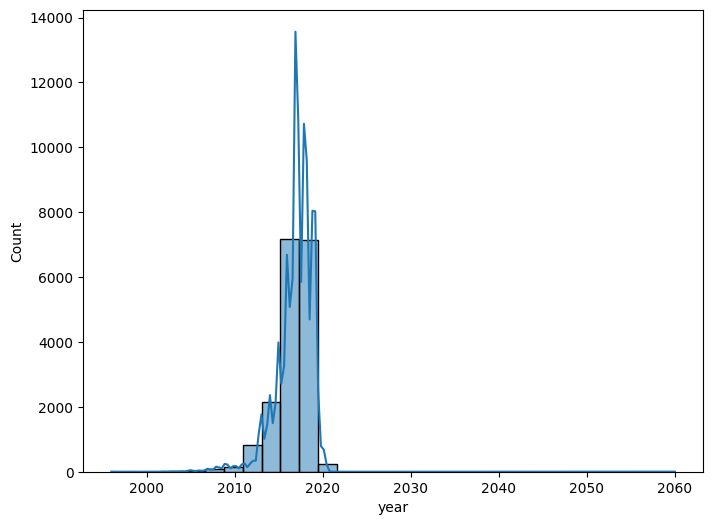

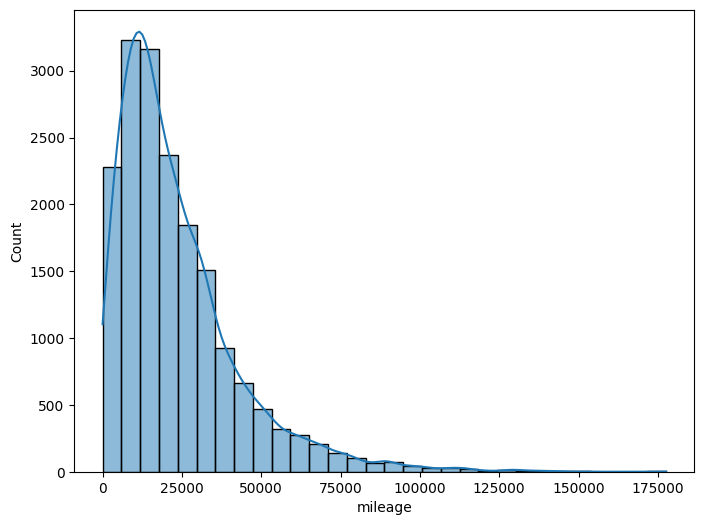

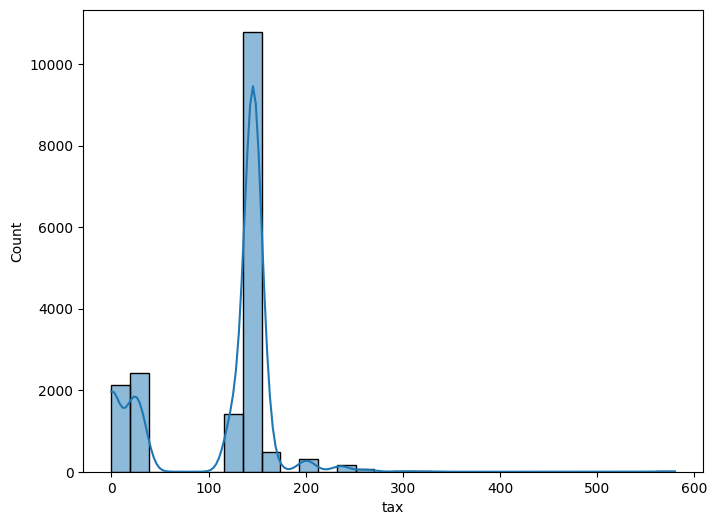

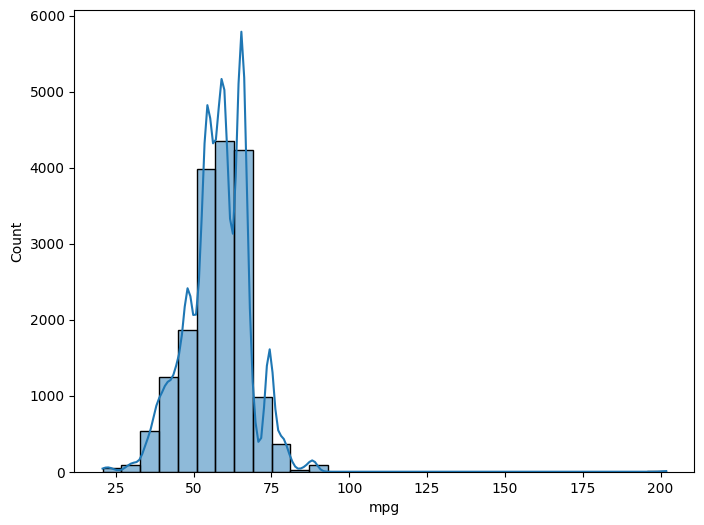

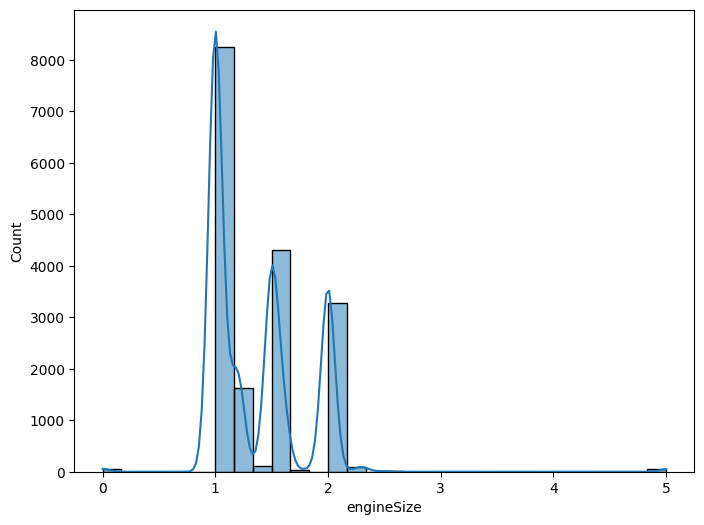

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(x=df[col], kde=True, bins=30)

In [ ]:
df['year'].value_counts()

,count
year,
2017,4854
2018,3982
2019,3152
2016,2314
2015,1355
2014,799
2013,606
2020,252
2012,115


In [ ]:
df.drop(df.loc[df['year']==2060].index, inplace=True)

In [ ]:
df['year'].value_counts()

,count
year,
2017,4854
2018,3982
2019,3152
2016,2314
2015,1355
2014,799
2013,606
2020,252
2012,115


In [ ]:
df.shape

(17811, 9)

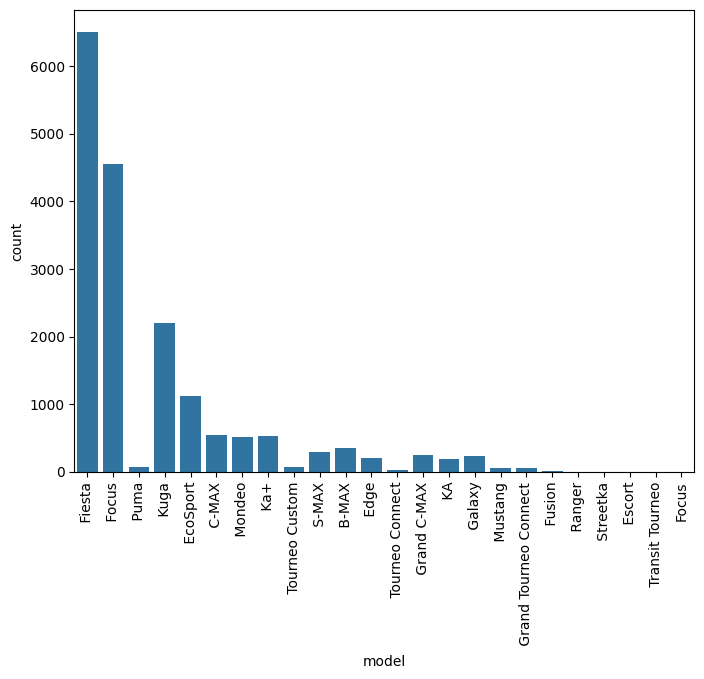

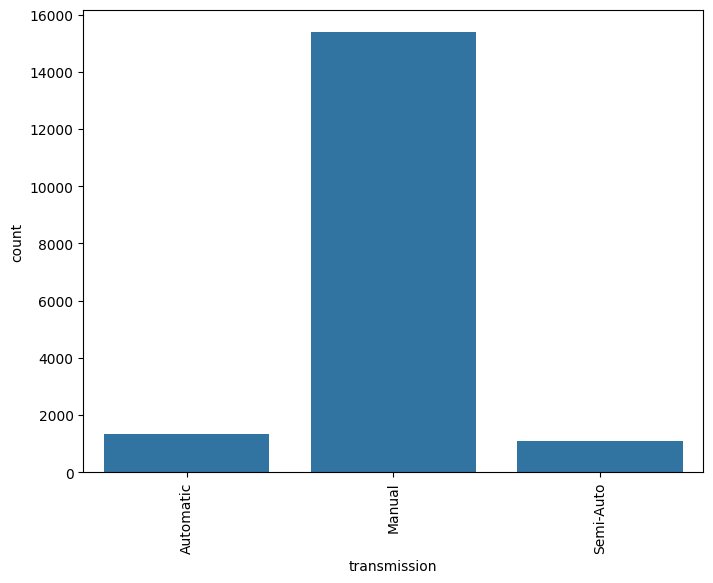

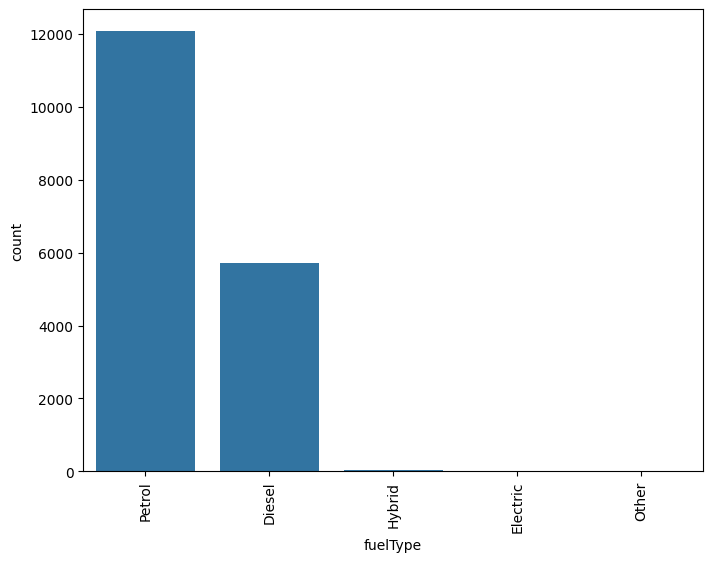

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=df[col])
    plt.xticks(rotation=90)

In [ ]:
df_one_hot_encode = pd.get_dummies(data=df, columns=categorical_cols)

In [ ]:
df_one_hot_encode = df_one_hot_encode.astype(int)

In [ ]:
df_one_hot_encode.head()

,year,price,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,2019,17500,10460,145,40,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2019,16500,1482,145,48,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_label_encode = df.copy()
for col in categorical_cols:
    df_label_encode[col] = encoder.fit_transform(df_label_encode[col])


In [ ]:
df_label_encode.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,12000,0,15944,4,150,57.7,1.0
1,6,2018,14000,1,9083,4,150,57.7,1.0
2,6,2017,13000,1,12456,4,150,57.7,1.0
3,5,2019,17500,1,10460,4,145,40.3,1.5
4,5,2019,16500,0,1482,4,145,48.7,1.0


In [ ]:
df_label_encode['model'].value_counts()

,count
model,
5,6508
6,4555
13,2208
2,1127
1,542
12,523
14,512
0,350
18,294


In [ ]:
df_label_encode['transmission'].value_counts()

,count
transmission,
1,15383
0,1353
2,1075


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
df_one_hot_encode[numeric_cols] = scaler.fit_transform(df_one_hot_encode[numeric_cols])
df_one_hot_encode.head()

,year,price,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.069100,12000,-0.382920,0.591483,-0.042378,-0.446973,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,0.562581,14000,-0.736260,0.591483,-0.042378,-0.446973,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,0.069100,13000,-0.562551,0.591483,-0.042378,-0.446973,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,1.056062,17500,-0.665344,0.510877,-1.720342,-0.446973,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,1.056062,16500,-1.127709,0.510877,-0.930712,-0.446973,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [ ]:
df_label_encode.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [ ]:
df_label_encode[['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']] = scaler.fit_transform(df_label_encode[['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']])
df_label_encode.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460297,0.069100,-0.056984,-2.668555,-0.382920,0.688234,0.591483,-0.020681,-0.810532
1,-0.210849,0.562581,0.365306,0.042312,-0.736260,0.688234,0.591483,-0.020681,-0.810532
2,-0.210849,0.069100,0.154161,0.042312,-0.562551,0.688234,0.591483,-0.020681,-0.810532
3,-0.460297,1.056062,1.104312,0.042312,-0.665344,0.688234,0.510877,-1.738002,0.345322
4,-0.460297,1.056062,0.893167,-2.668555,-1.127709,0.688234,0.510877,-0.908951,-0.810532


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = df_one_hot_encode.drop('price', axis=1)
y = df_one_hot_encode['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.8594654702356926

In [ ]:
X_label = df_label_encode.drop('price', axis=1)
y_label = df_label_encode['price']

In [ ]:
X_train, X_test,Y_train,Y_test = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(Y_test, y_pred)
r2

0.7549338742423937

# Final Words
- One Hot Encoding Gave Better Performance (85.9%) Than Label Encoding (75.9%)